In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import jax.numpy as jnp

digits = load_digits()

splits = train_test_split(digits.images, random_state=0)

images_train, images_test = map(jnp.asarray, splits)

print(f"{images_train.shape=}")
print(f"{images_test.shape=}")

images_train.shape=(1347, 8, 8)
images_test.shape=(450, 8, 8)


In [3]:
# Define VAE with Flax
import jax
import jax.numpy as jnp
from flax import nnx


In [4]:
class Encoder(nnx.Module):
    def __init__(self, input_size: int, intermediate_size: int, output_size: int, *, rngs: nnx.Rngs):
        self.rngs = rngs
        self.linear = nnx.Linear(input_size, intermediate_size, rngs=rngs)
        self.linear_mean = nnx.Linear(intermediate_size, output_size, rngs=rngs)
        self.linear_std = nnx.Linear(intermediate_size, output_size, rngs=rngs)

    def __call__(self, x: jax.Array) -> tuple[jax.Array, jax.Array, jax.Array]:
        x = self.linear(x)
        x = jax.nn.relu(x)

        mean = self.linear_mean(x)
        std = jnp.exp(self.linear_std(x))
        key = self.rngs.noise()

        latent_var = mean + std * jax.random.normal(key, mean.shape)
        return latent_var, mean, std


In [ ]:
class Decoder(nnx.Module):
    def __init__(self, input_size: int , intermediate_size: int, output_size: int, *, rngs: nnx.Rngs) -> None:
        self.linear1 = nnx.Linear(input_size, intermediate_size, rngs=rngs)
        self.linear2 = nnx.Linear(intermediate_size, output_size, rngs=rngs)
    def __call__(self, z: jax.Array) -> jax.Array:
        z = self.linear1(z)
        z = jax.nn.relu(z)
        logits = self.linear2(z)
        return logits

In [6]:
class VAE(nnx.Module):
    def __init__(
            self,
            image_shape: tuple[int, int], 
            hidden_size: int,
            latent_size: int,
            *, 
            rngs: nnx.Rngs) -> None:
        self.image_shape = image_shape
        self.latent_size = latent_size
        input_size = image_shape[0]*image_shape[1]
        self.encoder = Encoder(input_size, hidden_size, latent_size, rngs=rngs)
        self.decoder = Decoder(latent_size, hidden_size, input_size, rngs=rngs)

    def __call__(self, x: jax.Array) -> tuple[jax.Array, jax.Array, jax.Array]:
        x = jax.vmap(jax.numpy.ravel)(x) # flatten
        z, mean, std = self.encoder(x)
        logits = self.decoder(z)
        logits = jnp.reshape(logits, (-1, *self.image_shape))
        return logits, mean, std

In [13]:
# Loss function
import optax

def vae_loss(model: VAE, x: jax.Array):
    logits, mean, std = model(x)
    kl_loss = jnp.mean(0.5 * jnp.mean(
        -jnp.log(std ** 2) - 1.0 + std ** 2 + mean ** 2, axis=-1))
    reconstruction_loss = jnp.mean(
        optax.sigmoid_binary_cross_entropy(logits, x)
    )
    jax.debug.print("kl_loss: {}", kl_loss)
    jax.debug.print("reconstruction_loss: {}", reconstruction_loss)
    return reconstruction_loss + 0.1 * kl_loss


In [ ]:
model = VAE(
    image_shape=(8, 8),
    hidden_size=32, 
    latent_size=8,
    rngs=nnx.Rngs(0, noise=1),
)

optimizer = nnx.Optimizer(model, optax.adam(1e-3))

@nnx.jit 
def train_step(model: VAE, optimizer: nnx.Optimizer, x: jax.Array):
    loss, grads = nnx.value_and_grad(vae_loss)(model, x)
    optimizer.update(grads)
    return loss 

for epoch in range(2001):
    loss = train_step(model, optimizer, images_train)
    if epoch % 200 == 0:
        print(f'Epoch {epoch} loss: {loss}')

kl_loss: 101573.671875
reconstruction_loss: -9.882222175598145
Epoch 0 loss: 10147.4853515625
kl_loss: 41512.0546875
reconstruction_loss: -17.789182662963867
kl_loss: 19517.328125
reconstruction_loss: -14.053692817687988
kl_loss: 10482.7431640625
reconstruction_loss: -17.530529022216797
kl_loss: 6103.52587890625
reconstruction_loss: -14.77712631225586
kl_loss: 3826.579833984375
reconstruction_loss: -14.078912734985352
kl_loss: 2537.331298828125
reconstruction_loss: -13.116812705993652
kl_loss: 1776.679931640625
reconstruction_loss: -14.251022338867188
kl_loss: 1283.2626953125
reconstruction_loss: -12.294610023498535
kl_loss: 960.7326049804688
reconstruction_loss: -12.716197967529297
kl_loss: 747.1151733398438
reconstruction_loss: -12.468114852905273
kl_loss: 591.9276123046875
reconstruction_loss: -12.39665699005127
kl_loss: 482.0244140625
reconstruction_loss: -11.530012130737305
kl_loss: 401.44488525390625
reconstruction_loss: -12.022542953491211
kl_loss: 338.9151306152344
reconstructi

In [ ]:
model = VAE(
    image_shape=(8, 8),
    hidden_size=32, 
    latent_size=8,
    rngs=nnx.Rngs(0, noise=1),
)

optimizer = nnx.Optimizer(model, optax.adam(1e-3))

with jax.debug_nans(True):
    for epoch in range(2001):
        loss = train_step(model, optimizer, images_train)
        if epoch % 100 == 0:
            print(f'Epoch {epoch} loss: {loss}')

Epoch 0 loss: 10147.4853515625
Epoch 100 loss: -134.63352966308594
Invalid nan value encountered in the output of a jax.jit function. Calling the de-optimized version.


FloatingPointError: ('pjit', 'nan'). Because jax_config.debug_nans.value and/or config.jax_debug_infs is set, the de-optimized function (i.e., the function as if the `jit` decorator were removed) was called in an attempt to get a more precise error message. However, the de-optimized function did not produce invalid values during its execution. This behavior can result from `jit` optimizations causing the invalid value to be produced. It may also arise from having nan/inf literals as inputs or outputs, like `jax.jit(lambda ...: jax.numpy.nan)(...)`. 

It may be possible to avoid the invalid value by removing the `jit` decorator, at the cost of losing optimizations. 

If you see this error, consider opening a bug report at https://github.com/jax-ml/jax.

: 

In [15]:
%%capture
for epoch in range(2001):
    loss = train_step(model, optimizer, images_train)
    if epoch % 200 == 0:
        print(f'Epoch {epoch} loss: {loss}')

In [ ]:
images_normed = (digits.images / 16) > 0.5
splits = train_test_split(images_normed, random_state=0)
images_train, images_test = map(jnp.asarray, splits)

def vae_loss(model: VAE, x: jax.Array):
    logits, mean, std = model(x)

    kl_loss = jnp.mean(0.5 * jnp.mean(
        -jnp.log(std ** 2) - 1.0 + std ** 2 + mean ** 2, axis=-1))
    reconstruction_loss = jnp.mean(
        optax.sigmoid_binary_cross_entropy(logits, x)
    )
    return reconstruction_loss + 0.1 * kl_loss

model = VAE(
    image_shape=(8, 8),
    hidden_size=32,
    latent_size=8,
    rngs=nnx.Rngs(0, noise=1),
)

optimizer = nnx.Optimizer(model, optax.adam(1e-3))

for epoch in range(2001):
    loss = train_step(model, optimizer, images_train)
    if epoch % 500 == 0:
        print(f'Epoch {epoch} loss: {loss}')

Epoch 0 loss: 0.7713392972946167
Epoch 500 loss: 0.31550678610801697
Epoch 1000 loss: 0.2795470058917999
Epoch 1500 loss: 0.26905637979507446
Epoch 2000 loss: 0.2631511390209198


In [18]:
logits, mean, std = model(images_test)
images_pred = jax.nn.sigmoid(logits)

2026-01-05 15:31:46.110663: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-01-05 15:31:50.395269: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


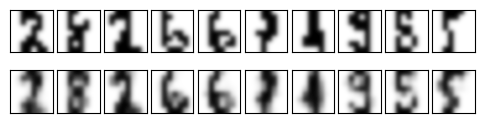

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 10, figsize=(6, 1.5),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
  ax[0, i].imshow(images_test[i], cmap='binary', interpolation='gaussian')
  ax[1, i].imshow(images_pred[i], cmap='binary', interpolation='gaussian')

2026-01-05 15:32:10.414864: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


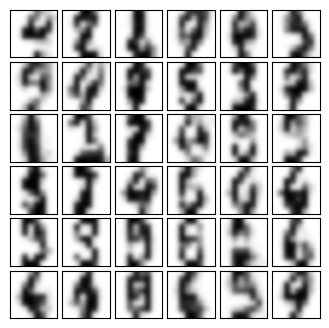

In [20]:
import numpy as np

# generate new images by sampling the latent space
z = np.random.normal(scale=1.5, size=(36, model.latent_size))
logits = model.decoder(z).reshape(-1, 8, 8)
images_gen = nnx.sigmoid(logits)

fig, ax = plt.subplots(6, 6, figsize=(4, 4),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(36):
  ax.flat[i].imshow(images_gen[i], cmap='binary', interpolation='gaussian')

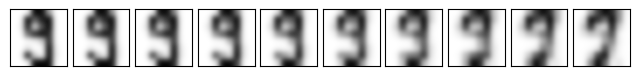

In [21]:
z, _, _ = model.encoder(images_train.reshape(-1, 64))
zrange = jnp.linspace(z[2], z[9], 10)

logits = model.decoder(zrange).reshape(-1, 8, 8)
images_gen = nnx.sigmoid(logits)

fig, ax = plt.subplots(1, 10, figsize=(8, 1),
                       subplot_kw={'xticks':[], 'yticks':[]},
                       gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i in range(10):
    ax.flat[i].imshow(images_gen[i], cmap='binary', interpolation='gaussian')